# NLHF Tournament Experiment v3

## AlphaRank для оценки файн-тюненых LLM моделей

Этот ноутбук реализует эксперимент по попарному сравнению 4 файн-тюненых моделей с использованием:
- **Матрицы побед/поражений** - подсчёт выигрышей между парами моделей
- **AlphaRank** - собственный вектор матрицы вероятностей (аля PageRank)
- **Elo-подход** - простое суммирование вероятностей побед

Идея: находим модель с наилучшей "выживаемостью" - ту, которая меньше всего проигрывает сильным кандидатам.

## 1. Импорт библиотек и настройка окружения

In [2]:
import os
import sys
import json
import random
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Add v3 to path
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

# Transformers
from transformers import (
    AutoModelForCausalLM, 
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import PeftModel

# Local modules
from tournament import Tournament, heuristic_arbiter
from scoring import score_summary, compare_responses
from visualization import (
    plot_win_matrix, 
    plot_probability_matrix,
    plot_rankings,
    create_summary_dashboard
)

# Configure
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Device setup
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Paths
MODEL_DIR = os.path.expanduser("~/.tune/models/")
LOG_DIR = "./logs"
os.makedirs(LOG_DIR, exist_ok=True)

# Experiment config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

/Users/macbook/Documents/learning/rl-projects/nlhf/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Загрузка и подготовка файн-тюненых моделей

Загружаем 4 модели для сравнения. Вы можете использовать:
- Разные чекпоинты одной модели (разные эпохи обучения)
- Разные LoRA адаптеры
- Модели разных размеров

Для демонстрации используем заглушки с эмуляцией разных "сильных" моделей.

In [3]:
# Configuration for models
# Replace these paths with your actual model paths

MODEL_CONFIGS = {
    "model_A": {
        "name": "Model A (Base SFT)",
        "path": "~/.tune/models/Llama-3.2-3B-SmallSFT/",
        "is_peft": False,
    },
    "model_B": {
        "name": "Model B (LoRA v1)", 
        "path": "~/.tune/checkpoints/TLDR/policy_epoch1/",
        "base_model": "~/.tune/models/Llama-3.2-3B-Base/",
        "is_peft": True,
    },
    "model_C": {
        "name": "Model C (LoRA v2)",
        "path": "~/.tune/checkpoints/TLDR/policy_epoch2/",
        "base_model": "~/.tune/models/Llama-3.2-3B-Base/",
        "is_peft": True,
    },
    "model_D": {
        "name": "Model D (LoRA v3)",
        "path": "~/.tune/checkpoints/TLDR/policy_epoch3/",
        "base_model": "~/.tune/models/Llama-3.2-3B-Base/",
        "is_peft": True,
    },
}

# Model names for tournament
MODEL_NAMES = list(MODEL_CONFIGS.keys())
print(f"Models to compare: {MODEL_NAMES}")

Models to compare: ['model_A', 'model_B', 'model_C', 'model_D']


In [4]:
# For demonstration without actual models, we'll create mock generators
# Replace this with actual model loading when you have the models

USE_MOCK_MODELS = True  # Set to False when using real models

if USE_MOCK_MODELS:
    print("⚠️ Using MOCK models for demonstration")
    print("Set USE_MOCK_MODELS = False and configure MODEL_CONFIGS for real models")
    
    # Mock response generator with different "strengths"
    class MockModel:
        def __init__(self, name: str, strength: float, style: str):
            self.name = name
            self.strength = strength  # 0-1, higher = better
            self.style = style  # "verbose", "concise", "balanced"
            
        def generate(self, prompt: str, max_length: int = 100) -> str:
            """Generate mock TL;DR response based on model characteristics."""
            # Extract key info from prompt
            words = prompt.split()
            key_words = [w for w in words if len(w) > 5][:10]
            
            # Different styles
            if self.style == "verbose":
                response = f"This post discusses {' and '.join(key_words[:3])}. "
                response += f"The main point is about {' '.join(key_words[3:6])}. "
                if random.random() < self.strength:
                    response += "Overall, the situation involves important considerations."
            elif self.style == "concise":
                response = f"{' '.join(key_words[:4])}."
            else:  # balanced
                response = f"Summary: {' '.join(key_words[:5])}. "
                if random.random() < self.strength:
                    response += f"Key aspects: {', '.join(key_words[5:8])}."
            
            # Add some randomness based on strength
            if random.random() > self.strength:
                # Lower strength = more mistakes
                response = response[:len(response)//2] + "..."
                
            return response
    
    # Create mock models with different characteristics
    MOCK_MODELS = {
        "model_A": MockModel("Model A", strength=0.6, style="verbose"),
        "model_B": MockModel("Model B", strength=0.75, style="concise"),
        "model_C": MockModel("Model C", strength=0.85, style="balanced"),
        "model_D": MockModel("Model D", strength=0.7, style="balanced"),
    }
    
    def get_response(model_name: str, prompt: str) -> str:
        """Get response from mock model."""
        return MOCK_MODELS[model_name].generate(prompt)
    
    print("\nMock model strengths:")
    for name, model in MOCK_MODELS.items():
        print(f"  {name}: strength={model.strength}, style={model.style}")

else:
    # Real model loading
    print("Loading real models...")
    
    # Quantization config for memory efficiency
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )
    
    # Load tokenizer (shared across models if same base)
    tokenizer = AutoTokenizer.from_pretrained(
        os.path.expanduser("~/.tune/models/Llama-3.2-3B-Base/")
    )
    tokenizer.pad_token = tokenizer.eos_token
    
    LOADED_MODELS = {}
    
    for model_id, config in MODEL_CONFIGS.items():
        print(f"Loading {config['name']}...")
        
        if config.get("is_peft", False):
            # Load base + LoRA adapter
            base_model = AutoModelForCausalLM.from_pretrained(
                os.path.expanduser(config["base_model"]),
                quantization_config=bnb_config,
                device_map="auto"
            )
            model = PeftModel.from_pretrained(
                base_model,
                os.path.expanduser(config["path"])
            )
        else:
            # Load full model
            model = AutoModelForCausalLM.from_pretrained(
                os.path.expanduser(config["path"]),
                quantization_config=bnb_config,
                device_map="auto"
            )
        
        LOADED_MODELS[model_id] = model
        print(f"  ✓ Loaded {model_id}")
    
    def get_response(model_name: str, prompt: str, max_new_tokens: int = 64) -> str:
        """Generate response from real model."""
        model = LOADED_MODELS[model_name]
        
        inputs = tokenizer(
            prompt + "\nTL;DR:", 
            return_tensors="pt",
            truncation=True,
            max_length=1024
        ).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id
            )
        
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        # Extract just the TL;DR part
        if "TL;DR:" in response:
            response = response.split("TL;DR:")[-1].strip()
        
        return response
    
    print(f"\n✓ All {len(LOADED_MODELS)} models loaded!")

⚠️ Using MOCK models for demonstration
Set USE_MOCK_MODELS = False and configure MODEL_CONFIGS for real models

Mock model strengths:
  model_A: strength=0.6, style=verbose
  model_B: strength=0.75, style=concise
  model_C: strength=0.85, style=balanced
  model_D: strength=0.7, style=balanced


## 3. Подготовка данных для сравнения

Загрузим промпты из TL;DR датасета для тестирования моделей.

In [5]:
# Load TL;DR prompts
from datasets import load_dataset

print("Loading TL;DR dataset...")
dataset = load_dataset("trl-lib/tldr", split="validation[:100]")

# Extract prompts
PROMPTS = [item["prompt"] for item in dataset]
print(f"Loaded {len(PROMPTS)} prompts")

# Show example
print("\n--- Example prompt ---")
print(PROMPTS[0][:500] + "...")

Loading TL;DR dataset...


Generating test split: 100%|██████████| 6553/6553 [00:00<00:00, 457196.37 examples/s]

Loaded 100 prompts

--- Example prompt ---
SUBREDDIT: r/AskReddit

TITLE: How do you get someone out of your head?

POST: Hi,
I'm 22, and I have been with my girlfriend for 5 years now. We recently moved together. We've always loved each other intensely.

Problem, I recently started to have feelings for an other person (a friend). This person has had a boyfriend for now 3 years, and has absolutely no ideas. Those feelings were so strong, it was hard to hide them. After 2 months of me being distant and really sad, my girlfriend forced me ...


## 4. Инициализация турнира и проведение матчей

Создаём Tournament объект и проводим попарные сравнения.
Арбитр оценивает качество TL;DR саммари по эвристике.

In [6]:
# Create tournament
tournament = Tournament(
    model_names=MODEL_NAMES,
    alpha=1.0,  # Softmax temperature
    log_dir=LOG_DIR
)

# Create arbiter using heuristic scoring
def heuristic_arbiter_fn(prompt: str, response_a: str, response_b: str) -> Tuple[str, float, float]:
    """Arbiter based on heuristic TL;DR scoring."""
    score_a = score_summary(response_a, prompt)
    score_b = score_summary(response_b, prompt)
    
    margin = 2.0  # Score difference for clear win
    if score_a > score_b + margin:
        winner = "a"
    elif score_b > score_a + margin:
        winner = "b"
    else:
        winner = "tie"
    
    return winner, score_a, score_b

tournament.set_arbiter(heuristic_arbiter_fn)
print("Tournament initialized with heuristic arbiter")

Tournament initialized with heuristic arbiter


In [7]:
# Run tournament matches
NUM_PROMPTS = 50  # Number of prompts to use
MATCHES_PER_PAIR = 2  # How many times each pair competes on each prompt

print(f"Running tournament with {NUM_PROMPTS} prompts, {MATCHES_PER_PAIR} matches per pair")
print(f"Total expected matches: ~{NUM_PROMPTS * MATCHES_PER_PAIR * len(MODEL_NAMES)}")

# Store all match details for analysis
all_matches = []

for prompt_idx in tqdm(range(NUM_PROMPTS), desc="Running matches"):
    prompt = PROMPTS[prompt_idx]
    
    for _ in range(MATCHES_PER_PAIR):
        # Random pair selection
        model_a, model_b = random.sample(MODEL_NAMES, 2)
        
        # Generate responses
        response_a = get_response(model_a, prompt)
        response_b = get_response(model_b, prompt)
        
        # Run match
        result = tournament.run_match(
            model_a=model_a,
            model_b=model_b,
            prompt=prompt,
            response_a=response_a,
            response_b=response_b
        )
        
        all_matches.append({
            "prompt_idx": prompt_idx,
            "model_a": model_a,
            "model_b": model_b,
            "response_a": response_a,
            "response_b": response_b,
            "winner": result.winner,
            "score_a": result.score_a,
            "score_b": result.score_b
        })

print(f"\n✓ Completed {len(all_matches)} matches")

Running tournament with 50 prompts, 2 matches per pair
Total expected matches: ~400


Running matches: 100%|██████████| 50/50 [00:00<00:00, 2789.25it/s]


✓ Completed 100 matches


## 5. Построение и визуализация матрицы побед

Матрица $W$ где $W_{ij}$ = количество побед модели $i$ над моделью $j$.

Win Matrix (rows=winner, cols=loser):
--------------------------------------------------
         model_A   model_B   model_C   model_D
 model_A:      0.0      14.5      19.5      11.5
 model_B:      0.5       0.0       0.5       6.0
 model_C:      3.5       7.5       0.0      11.0
 model_D:      2.5      17.0       6.0       0.0


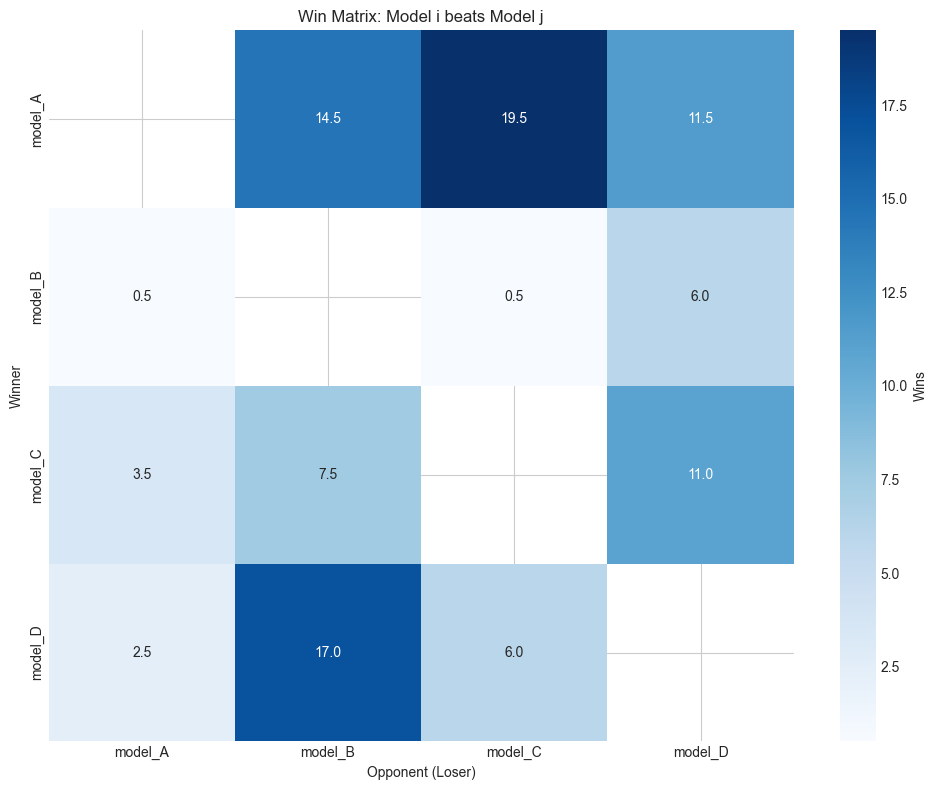

In [8]:
# Get win matrix
win_matrix = tournament.get_win_matrix()

print("Win Matrix (rows=winner, cols=loser):")
print("-" * 50)

# Pretty print
header = "        " + "  ".join([f"{name:>8}" for name in MODEL_NAMES])
print(header)
for i, row_name in enumerate(MODEL_NAMES):
    row = "  ".join([f"{win_matrix[i, j]:8.1f}" for j in range(len(MODEL_NAMES))])
    print(f"{row_name:>8}: {row}")

# Visualize
fig = plot_win_matrix(
    win_matrix, 
    MODEL_NAMES,
    title="Win Matrix: Model i beats Model j",
    save_path=os.path.join(LOG_DIR, "win_matrix.png")
)
plt.show()

## 6. Нормализация матрицы с помощью Softmax (AlphaRank)

Применяем softmax по столбцам:

$$P_{ij} = \frac{e^{\alpha \cdot W_{ij}}}{\sum_k e^{\alpha \cdot W_{kj}}}$$

где $\alpha$ - температурный параметр для "раздвигания" близких значений.

Probability Matrix (softmax normalized):
P[i,j] = probability that model i beats model j
--------------------------------------------------
         model_A   model_B   model_C   model_D
 model_A:    0.021     0.076     1.000     0.621
 model_B:    0.034     0.000     0.000     0.003
 model_C:    0.691     0.000     0.000     0.377
 model_D:    0.254     0.924     0.000     0.000


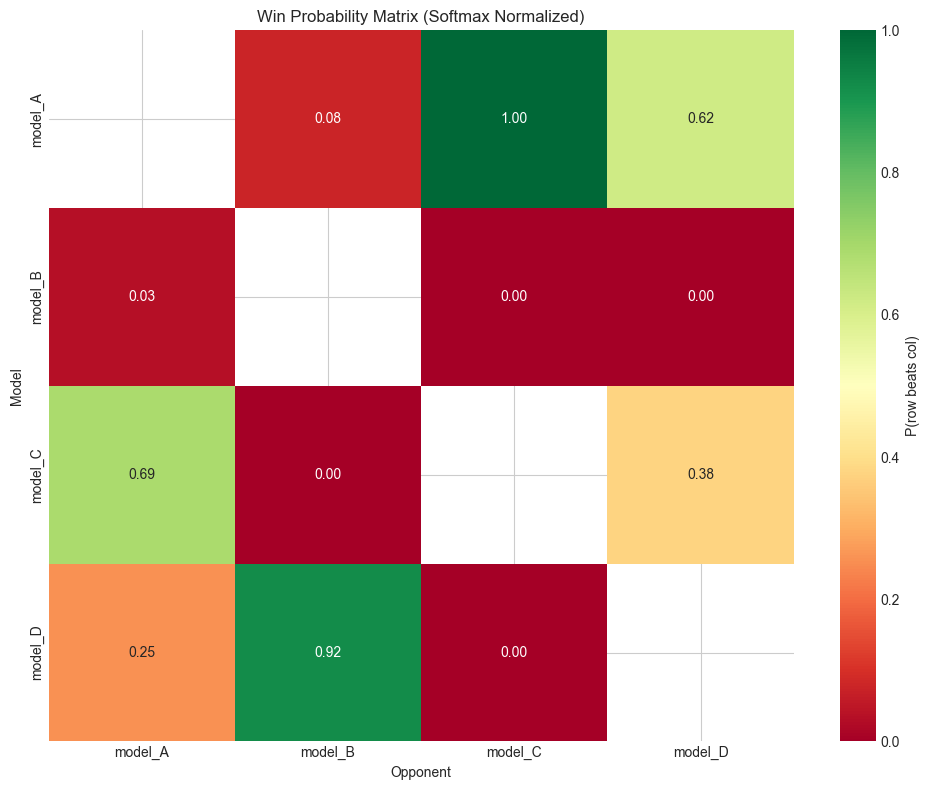

In [9]:
# Get probability matrix with softmax
prob_matrix = tournament.get_probability_matrix(method="softmax")

print("Probability Matrix (softmax normalized):")
print("P[i,j] = probability that model i beats model j")
print("-" * 50)

header = "        " + "  ".join([f"{name:>8}" for name in MODEL_NAMES])
print(header)
for i, row_name in enumerate(MODEL_NAMES):
    row = "  ".join([f"{prob_matrix[i, j]:8.3f}" for j in range(len(MODEL_NAMES))])
    print(f"{row_name:>8}: {row}")

# Visualize
fig = plot_probability_matrix(
    prob_matrix,
    MODEL_NAMES,
    title="Win Probability Matrix (Softmax Normalized)",
    save_path=os.path.join(LOG_DIR, "probability_matrix.png")
)
plt.show()

## 7. Вычисление AlphaRank (собственный вектор)

AlphaRank вычисляет "выживаемость" каждой модели как стационарное распределение марковской цепи:
- Переходы между состояниями определяются вероятностями побед
- Собственный вектор с eigenvalue=1 даёт распределение "времени" в каждом состоянии

Это похоже на **PageRank** - модель, которая "побеждает" чаще, получает больше "ссылок" от других.

In [10]:
# Calculate AlphaRank scores
alpharank_scores = tournament.get_alpharank_scores()

print("AlphaRank Scores (stationary distribution):")
print("-" * 40)

alpharank_rankings = list(zip(MODEL_NAMES, alpharank_scores))
alpharank_rankings.sort(key=lambda x: x[1], reverse=True)

for rank, (name, score) in enumerate(alpharank_rankings, 1):
    bar = "█" * int(score * 50)
    print(f"{rank}. {name:>10}: {score:.4f}  {bar}")

print(f"\nSum of scores: {sum(alpharank_scores):.4f} (should be ≈1.0)")

AlphaRank Scores (stationary distribution):
----------------------------------------
1.    model_A: 0.4716  ███████████████████████
2.    model_C: 0.3766  ██████████████████
3.    model_D: 0.1351  ██████
4.    model_B: 0.0166  

Sum of scores: 1.0000 (should be ≈1.0)


## 8. Сравнение с Elo-подходом

Elo-подход: просто суммируем строку матрицы вероятностей.
Это даёт среднюю вероятность победы над всеми соперниками.

In [11]:
# Calculate Elo-like scores
elo_scores = tournament.get_elo_scores()

print("Elo-like Scores (sum of win probabilities):")
print("-" * 40)

elo_rankings = list(zip(MODEL_NAMES, elo_scores))
elo_rankings.sort(key=lambda x: x[1], reverse=True)

for rank, (name, score) in enumerate(elo_rankings, 1):
    bar = "█" * int(score * 10)
    print(f"{rank}. {name:>10}: {score:.4f}  {bar}")

# Compare rankings
print("\n" + "=" * 50)
print("RANKING COMPARISON")
print("=" * 50)
print(f"{'Rank':<6} {'AlphaRank':<15} {'Elo':<15}")
print("-" * 36)

for i in range(len(MODEL_NAMES)):
    alpha_name = alpharank_rankings[i][0]
    elo_name = elo_rankings[i][0]
    match = "✓" if alpha_name == elo_name else "≠"
    print(f"{i+1:<6} {alpha_name:<15} {elo_name:<15} {match}")

Elo-like Scores (sum of win probabilities):
----------------------------------------
1.    model_A: 2.6359  ██████████████████████████
2.    model_C: 1.7367  █████████████████
3.    model_D: 1.2706  ████████████
4.    model_B: 0.3567  ███

RANKING COMPARISON
Rank   AlphaRank       Elo            
------------------------------------
1      model_A         model_A         ✓
2      model_C         model_C         ✓
3      model_D         model_D         ✓
4      model_B         model_B         ✓


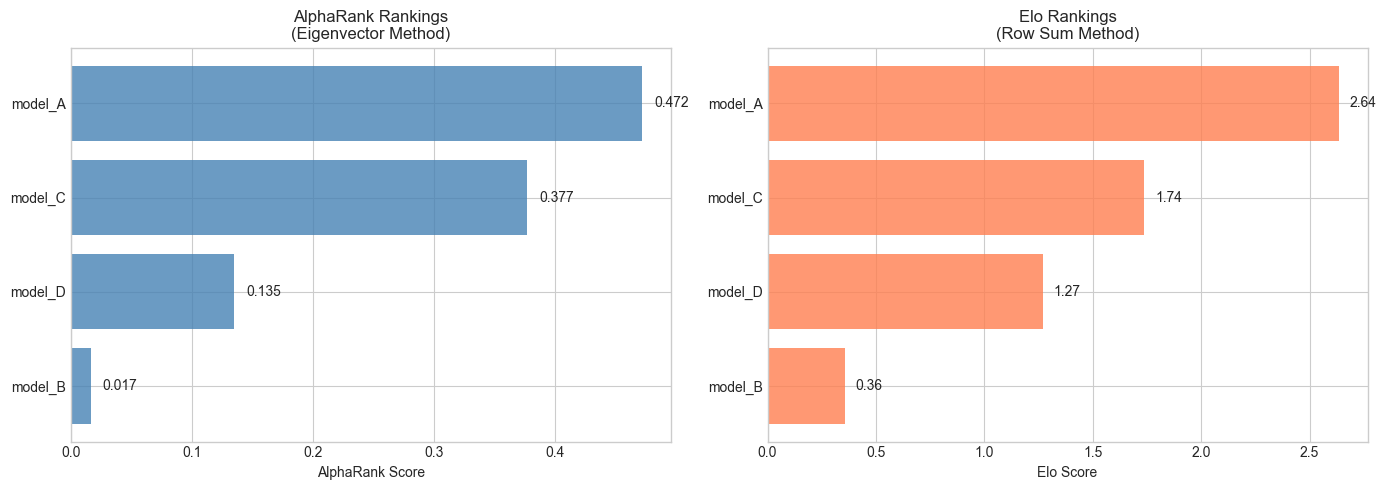

In [12]:
# Visualize both rankings side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AlphaRank
ax1 = axes[0]
names_alpha = [r[0] for r in alpharank_rankings]
scores_alpha = [r[1] for r in alpharank_rankings]
bars1 = ax1.barh(range(len(names_alpha)), scores_alpha, color='steelblue', alpha=0.8)
ax1.set_yticks(range(len(names_alpha)))
ax1.set_yticklabels(names_alpha)
ax1.invert_yaxis()
ax1.set_xlabel('AlphaRank Score')
ax1.set_title('AlphaRank Rankings\n(Eigenvector Method)')
for bar, score in zip(bars1, scores_alpha):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=10)

# Elo
ax2 = axes[1]
names_elo = [r[0] for r in elo_rankings]
scores_elo = [r[1] for r in elo_rankings]
bars2 = ax2.barh(range(len(names_elo)), scores_elo, color='coral', alpha=0.8)
ax2.set_yticks(range(len(names_elo)))
ax2.set_yticklabels(names_elo)
ax2.invert_yaxis()
ax2.set_xlabel('Elo Score')
ax2.set_title('Elo Rankings\n(Row Sum Method)')
for bar, score in zip(bars2, scores_elo):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "rankings_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

## 9. Анализ примеров побед и поражений

Рассмотрим конкретные примеры:
- Когда "слабая" модель побеждает "сильную"
- Характерные паттерны победителей

In [14]:
# Analyze win/loss patterns
def analyze_matches(matches: List[dict], model_rankings: List[Tuple[str, float]]):
    """Analyze match patterns."""
    
    # Create rank lookup
    rank_lookup = {name: rank for rank, (name, _) in enumerate(model_rankings, 1)}
    
    # Find upsets (lower-ranked beats higher-ranked)
    upsets = []
    for match in matches:
        if match["winner"] == "tie":
            continue
            
        model_a, model_b = match["model_a"], match["model_b"]
        rank_a, rank_b = rank_lookup[model_a], rank_lookup[model_b]
        
        # Determine who won
        if match["winner"] == model_a:
            winner, loser = model_a, model_b
            winner_rank, loser_rank = rank_a, rank_b
        else:
            winner, loser = model_b, model_a
            winner_rank, loser_rank = rank_b, rank_a
        
        # Upset = lower-ranked (higher number) beats higher-ranked (lower number)
        if winner_rank > loser_rank:
            upsets.append({
                "winner": winner,
                "loser": loser,
                "winner_rank": winner_rank,
                "loser_rank": loser_rank,
                "prompt_idx": match.get("prompt_idx", -1),
                "winner_response": match["response_a"] if match["winner"] == model_a else match["response_b"],
                "loser_response": match["response_b"] if match["winner"] == model_a else match["response_a"],
                "winner_score": match["score_a"] if match["winner"] == model_a else match["score_b"],
                "loser_score": match["score_b"] if match["winner"] == model_a else match["score_a"]
            })
    
    return upsets

# Get upsets based on AlphaRank
upsets = analyze_matches(all_matches, alpharank_rankings)
print(f"Found {len(upsets)} upsets (lower-ranked beat higher-ranked)")

# Show statistics
upset_counts = {}
for u in upsets:
    key = f"{u['winner']} beat {u['loser']}"
    upset_counts[key] = upset_counts.get(key, 0) + 1

print("\nUpset frequency:")
for key, count in sorted(upset_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {key}: {count} times")

Found 5 upsets (lower-ranked beat higher-ranked)

Upset frequency:
  model_C beat model_A: 2 times
  model_D beat model_A: 1 times
  model_D beat model_C: 1 times
  model_B beat model_D: 1 times


In [15]:
# Show example upsets
if upsets:
    print("=" * 80)
    print("EXAMPLE UPSETS (lower-ranked beats higher-ranked)")
    print("=" * 80)
    
    for i, upset in enumerate(upsets[:3], 1):
        print(f"\n--- Upset #{i} ---")
        print(f"Winner: {upset['winner']} (rank {upset['winner_rank']}) beat {upset['loser']} (rank {upset['loser_rank']})")
        
        # Get prompt from PROMPTS if available
        prompt_idx = upset.get("prompt_idx", -1)
        if prompt_idx >= 0 and prompt_idx < len(PROMPTS):
            print(f"\nPrompt snippet: {PROMPTS[prompt_idx][:200]}...")
        
        print(f"\n🏆 Winner response (score={upset['winner_score']:.1f}):")
        print(f"   {upset['winner_response'][:150]}...")
        print(f"\n❌ Loser response (score={upset['loser_score']:.1f}):")
        print(f"   {upset['loser_response'][:150]}...")
        print()
else:
    print("No upsets found - rankings are very consistent!")

EXAMPLE UPSETS (lower-ranked beats higher-ranked)

--- Upset #1 ---
Winner: model_C (rank 2) beat model_A (rank 1)

Prompt snippet: SUBREDDIT: r/pettyrevenge

TITLE: So, my mom woke me up with a loud TV.

POST: She was in her living room, watching TV. This was at about 8:30 in the morning, and she was exercising. She turned the TV...

🏆 Winner response (score=19.1):
   Summary: SUBREDDIT: r/pettyrevenge TITLE: living watching. Key aspects: morning,, exercising., turned....

❌ Loser response (score=9.5):
   This post discusses SUBREDDIT: and r/pettyrevenge and TITLE:. The main point is abou......


--- Upset #2 ---
Winner: model_D (rank 3) beat model_A (rank 1)

Prompt snippet: SUBREDDIT: r/AskReddit

TITLE: Reddit, I think our family dog just consumed a significant amount of chocolate. What do I do?

POST: Okay so my father and I went out to dinner tonight and left the dog ...

🏆 Winner response (score=19.0):
   Summary: SUBREDDIT: r/AskReddit TITLE: Reddit, family. Key aspects: consum

## 10. Визуализация Attention (для реальных моделей)

При использовании реальных моделей можно визуализировать attention weights для понимания того, на какие токены модель обращает внимание при генерации.

In [16]:
def visualize_attention(
    model,
    tokenizer,
    text: str,
    layer_idx: int = -1,
    head_idx: Optional[int] = None,
    figsize: Tuple[int, int] = (12, 8)
):
    """
    Visualize attention weights for a given text.
    
    Args:
        model: HuggingFace model with output_attentions=True support
        tokenizer: Tokenizer
        text: Input text
        layer_idx: Which layer's attention to visualize (-1 = last)
        head_idx: Which head to show (None = average all heads)
        figsize: Figure size
    """
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    # Forward with attention output
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # Get attention from specified layer
    # Shape: [batch, num_heads, seq_len, seq_len]
    attention = outputs.attentions[layer_idx][0]  # Remove batch dim
    
    if head_idx is not None:
        attention = attention[head_idx]  # [seq_len, seq_len]
    else:
        attention = attention.mean(dim=0)  # Average over heads
    
    attention = attention.cpu().numpy()
    
    # Get tokens
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Limit tokens for visibility
    max_tokens = 50
    if len(tokens) > max_tokens:
        tokens = tokens[:max_tokens]
        attention = attention[:max_tokens, :max_tokens]
    
    sns.heatmap(
        attention,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="Blues",
        ax=ax
    )
    
    ax.set_xlabel("Key Tokens")
    ax.set_ylabel("Query Tokens")
    ax.set_title(f"Attention Weights (Layer {layer_idx})")
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    return fig

# Note: This function requires real models
if not USE_MOCK_MODELS:
    print("Visualizing attention for top-ranked model...")
    top_model_name = alpharank_rankings[0][0]
    top_model = LOADED_MODELS[top_model_name]
    
    sample_text = PROMPTS[0][:500] + "\nTL;DR:"
    fig = visualize_attention(top_model, tokenizer, sample_text)
    plt.savefig(os.path.join(LOG_DIR, "attention_example.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Attention visualization requires real models")
    print("Set USE_MOCK_MODELS = False to enable this feature")

⚠️ Attention visualization requires real models
Set USE_MOCK_MODELS = False to enable this feature


## 11. Сводная визуализация и сохранение результатов

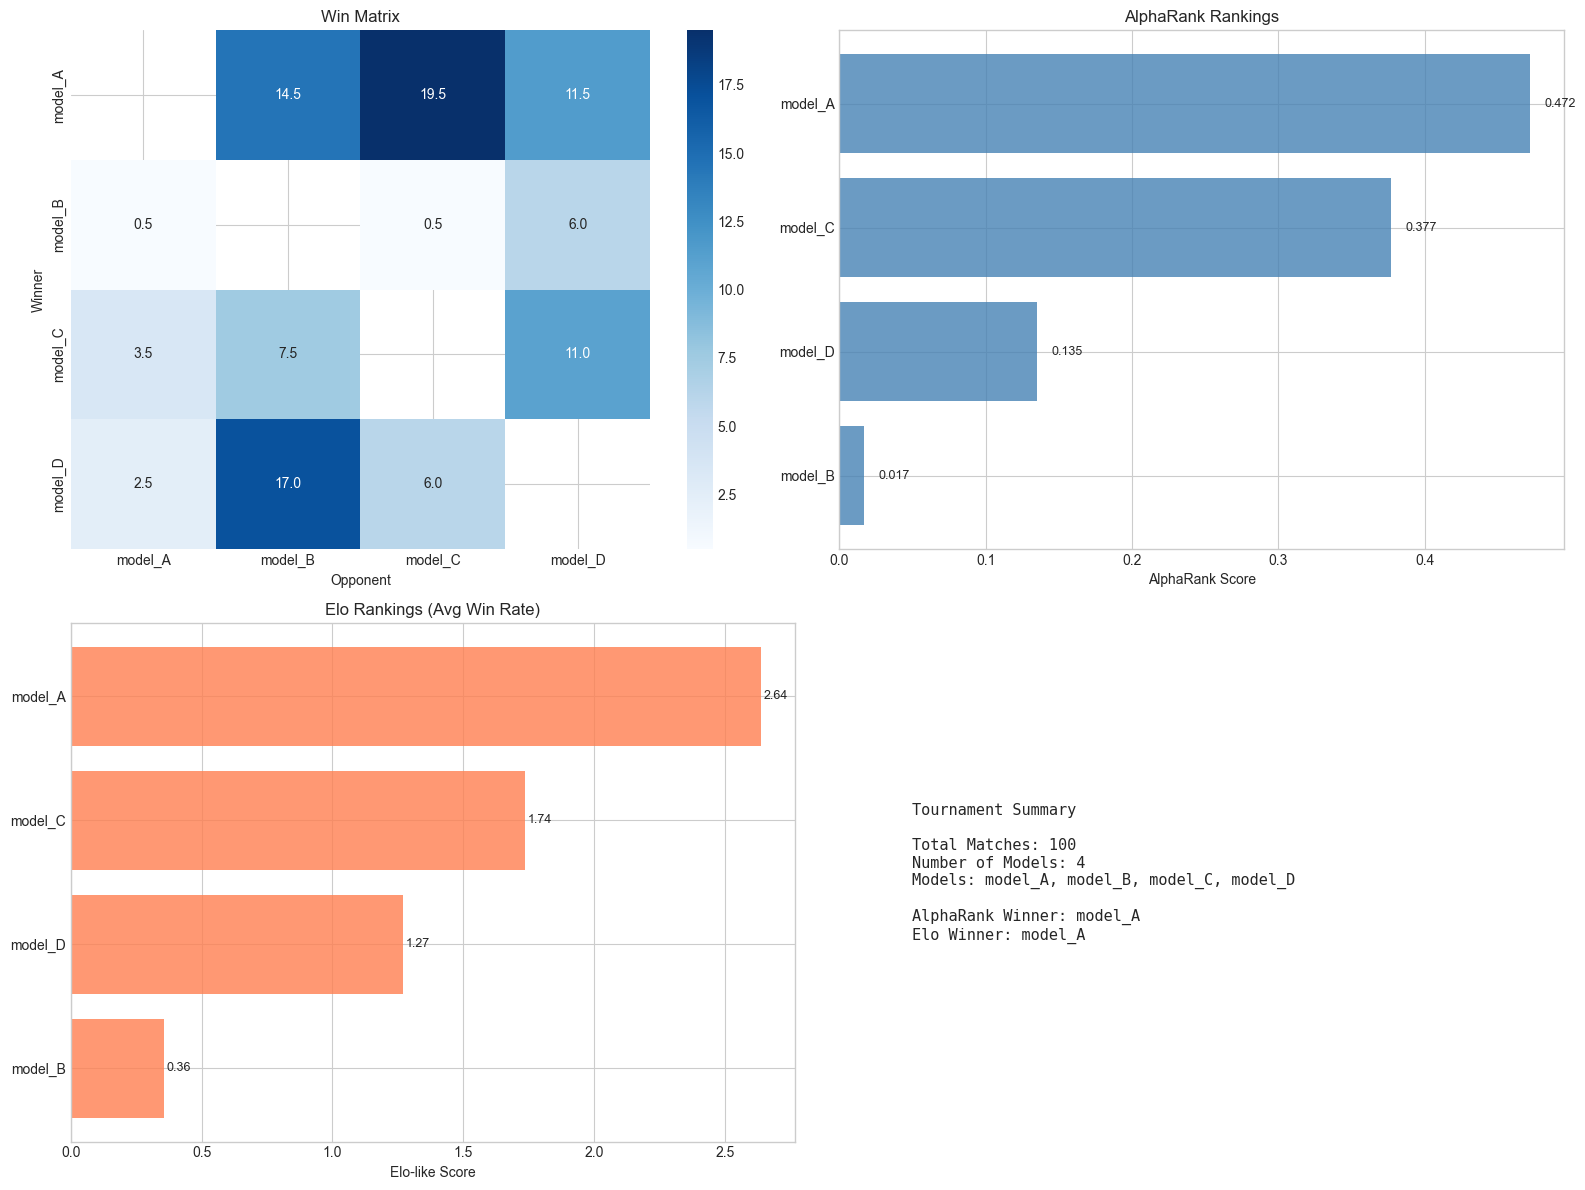

In [17]:
# Create summary dashboard
tournament_results = {
    "model_names": MODEL_NAMES,
    "win_matrix": win_matrix.tolist(),
    "alpharank_scores": alpharank_scores.tolist(),
    "elo_scores": elo_scores.tolist(),
    "total_matches": len(all_matches)
}

fig = create_summary_dashboard(
    tournament_results,
    save_path=os.path.join(LOG_DIR, "tournament_dashboard.png")
)
plt.show()

In [18]:
# Save all results
results_path = tournament.save_results("tournament_results.json")
print(f"Results saved to: {results_path}")

# Save detailed match log
with open(os.path.join(LOG_DIR, "match_details.json"), "w") as f:
    json.dump(all_matches, f, indent=2, ensure_ascii=False)
print(f"Match details saved to: {os.path.join(LOG_DIR, 'match_details.json')}")

# Summary
print("\n" + "=" * 60)
print("TOURNAMENT SUMMARY")
print("=" * 60)
print(f"Total matches: {len(all_matches)}")
print(f"Number of prompts: {NUM_PROMPTS}")
print(f"Number of models: {len(MODEL_NAMES)}")
print(f"\n🏆 WINNER (AlphaRank): {alpharank_rankings[0][0]} (score: {alpharank_rankings[0][1]:.4f})")
print(f"🏆 WINNER (Elo): {elo_rankings[0][0]} (score: {elo_rankings[0][1]:.2f})")
print("\nFiles saved in:", LOG_DIR)

Results saved to: ./logs/tournament_results.json
Match details saved to: ./logs/match_details.json

TOURNAMENT SUMMARY
Total matches: 100
Number of prompts: 50
Number of models: 4

🏆 WINNER (AlphaRank): model_A (score: 0.4716)
🏆 WINNER (Elo): model_A (score: 2.64)

Files saved in: ./logs


## 12. Выводы и следующие шаги

### Что мы получили:
1. **Матрица побед $W$** - сколько раз каждая модель победила каждую другую
2. **Матрица вероятностей $P$** - softmax нормализация по столбцам
3. **AlphaRank** - собственный вектор, показывающий "выживаемость" 
4. **Elo-score** - простая сумма вероятностей побед

### Интерпретация:
- **AlphaRank** учитывает транзитивность: победа над сильным соперником важнее, чем над слабым
- **Elo** - прямолинейный подход, может не учитывать структуру побед

### Следующие шаги:
1. Использовать LLM-арбитр (GPT-4, Claude) вместо эвристики
2. Визуализировать attention для анализа "почему модель победила"
3. Разбить по категориям вопросов (математика, общие знания, логика)
4. Использовать AlphaRank scores как награды для RLHF